# LEGO Minifigure Dataset — Exploratory Data Analysis

This notebook analyses the dataset used for LEGO minifigure classification.  
All paths are relative to the `Assignment 2/` root folder.

In [1]:
import json
import os
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

# ── paths ──────────────────────────────────────────────────────────────────
ROOT = Path("..")
META = ROOT / "minifigs.json"
IMG_DIR = ROOT / "images"

random.seed(42)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

with open(META) as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f"Records : {len(df):,}")
print(f"Columns : {list(df.columns)}")
df.head(3)

Records : 17,362
Columns : ['id', 'name', 'link', 'year', 'img_url', 'minifig_number', 'category', 'subcategory', 'year_released', 'set_id', 'current_value_new', 'current_value_used', 'character_name', 'img_local_path', 'themes']


,id,name,link,year,img_url,minifig_number,category,subcategory,year_released,set_id,current_value_new,current_value_used,character_name,img_local_path,themes
0,1,"LEGOLAND - Black Torso, Black Legs, Black Cowb...",/minifigs/old040/legoland-black-torso-black-le...,1975,https://img.bricklink.com/ItemImage/MN/0/old04...,OLD040,LEGOLAND,General,1975,1 set,~€5.28,~€1.85,None,images/OLD040.jpg,[LEGOLAND]
1,2,"LEGOLAND - Black Torso, Black Legs, Black Hat",/minifigs/old011/legoland-black-torso-black-le...,1975,https://img.bricklink.com/ItemImage/MN/0/old01...,OLD011,LEGOLAND,General,1975,7 sets,Not known,~€1.53,None,images/OLD011.jpg,"[Basic, LEGOLAND, Universal Building Set]"
2,3,"LEGOLAND - Black Torso, Black Legs, White Hat",/minifigs/old009/legoland-black-torso-black-le...,1975,https://img.bricklink.com/ItemImage/MN/0/old00...,OLD009,LEGOLAND,General,1975,2 sets,~€3.37,~€1.42,None,images/OLD009.jpg,[LEGOLAND]


## 1. Dataset Overview

In [2]:
# Basic counts
n_total      = len(df)
n_categories = df["category"].nunique()
n_subcats    = df["subcategory"].nunique()
n_missing_img = df["img_local_path"].isna().sum()
year_min, year_max = df["year"].min(), df["year"].max()

summary = pd.DataFrame({
    "Metric": ["Total minifigures", "Unique categories", "Unique subcategories",
                "Year range", "Missing images"],
    "Value":  [f"{n_total:,}", n_categories, n_subcats,
                f"{int(year_min)} – {int(year_max)}", n_missing_img]
})
summary.set_index("Metric", inplace=True)
summary

,Value
Metric,
Total minifigures,"17,362"
Unique categories,122
Unique subcategories,518
Year range,1975 – 2026
Missing images,1


In [3]:
# Null / missing per column
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(nulls.to_string())

Columns with missing values:
character_name    7883
img_local_path       1


## 2. Class Distribution

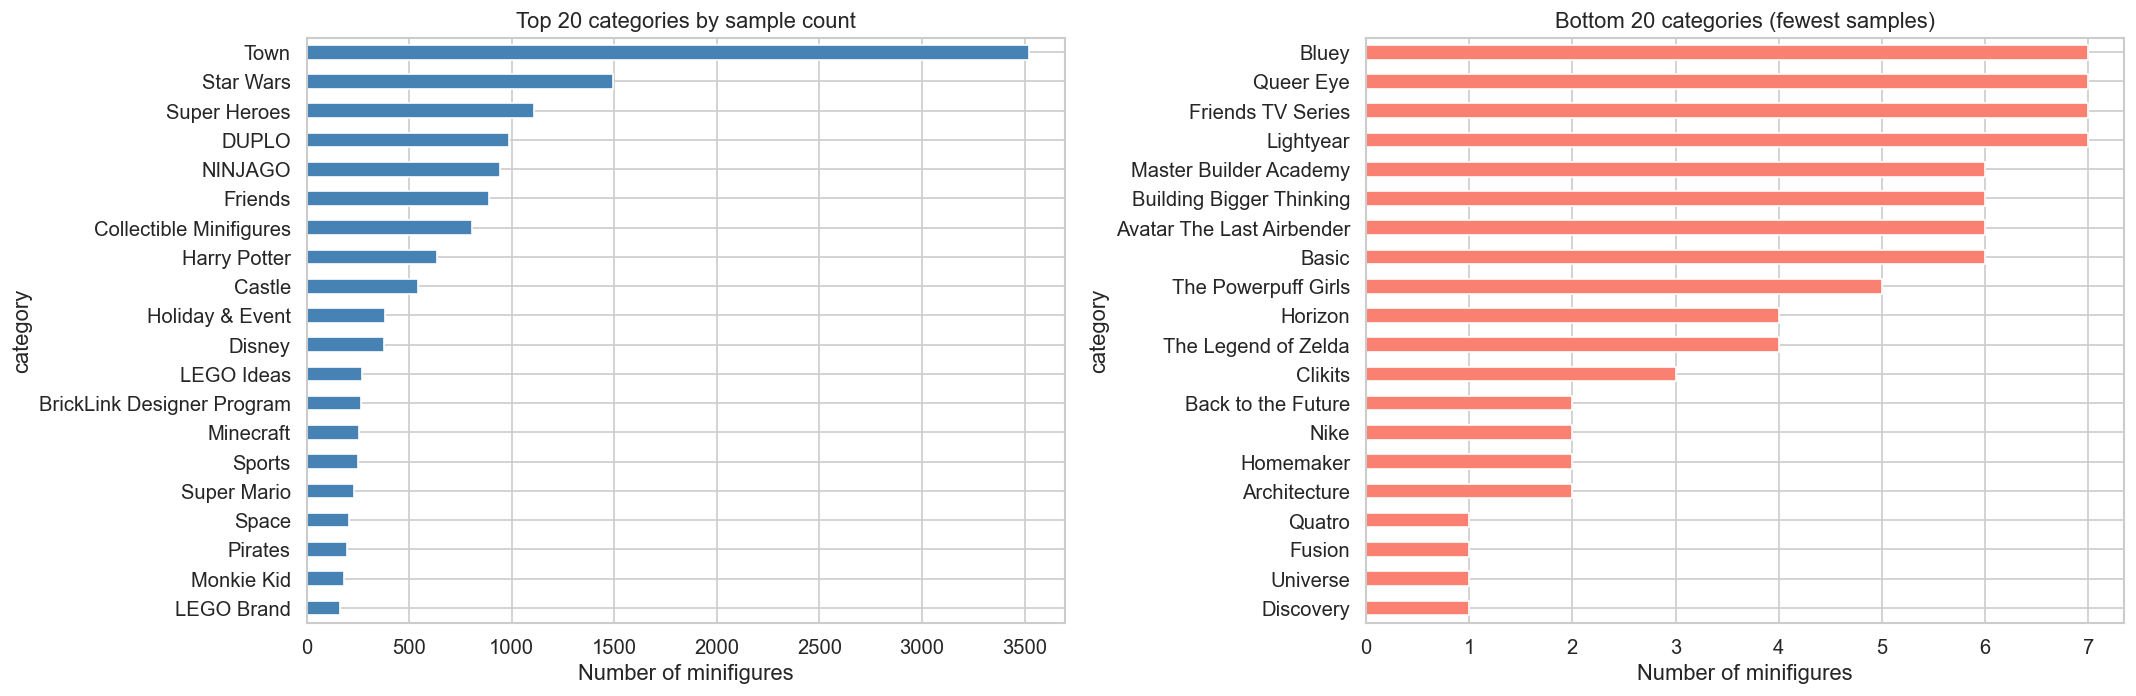

Largest class : Town  (3,522 samples)
Smallest class: Discovery (1 sample)
Imbalance ratio: 3522x


In [4]:
cat_counts = df["category"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20
cat_counts.head(20).sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_title("Top 20 categories by sample count")
axes[0].set_xlabel("Number of minifigures")

# Bottom 20
cat_counts.tail(20).sort_values().plot(
    kind="barh", ax=axes[1], color="salmon"
)
axes[1].set_title("Bottom 20 categories (fewest samples)")
axes[1].set_xlabel("Number of minifigures")

plt.tight_layout()
plt.savefig(ROOT / "results" / "eda_class_distribution.png", bbox_inches="tight")
plt.show()

print(f"Largest class : {cat_counts.index[0]}  ({cat_counts.iloc[0]:,} samples)")
print(f"Smallest class: {cat_counts.index[-1]} ({cat_counts.iloc[-1]} sample)")
print(f"Imbalance ratio: {cat_counts.iloc[0] / cat_counts.iloc[-1]:.0f}x")

## 3. Class Imbalance Analysis

In [5]:
thresholds = [10, 50, 100, 200, 500]
rows = []
for t in thresholds:
    below = (cat_counts < t).sum()
    pct_classes = below / len(cat_counts) * 100
    pct_samples = cat_counts[cat_counts < t].sum() / n_total * 100
    rows.append({"Threshold": f"< {t} samples",
                 "# Classes": below,
                 "% of Classes": f"{pct_classes:.1f}%",
                 "% of Total Samples": f"{pct_samples:.1f}%"})

imbalance_df = pd.DataFrame(rows).set_index("Threshold")
print("Imbalance summary:")
imbalance_df

Imbalance summary:


,# Classes,% of Classes,% of Total Samples
Threshold,,,
< 10 samples,24,19.7%,0.7%
< 50 samples,78,63.9%,8.5%
< 100 samples,94,77.0%,14.8%
< 200 samples,105,86.1%,24.2%
< 500 samples,113,92.6%,37.1%


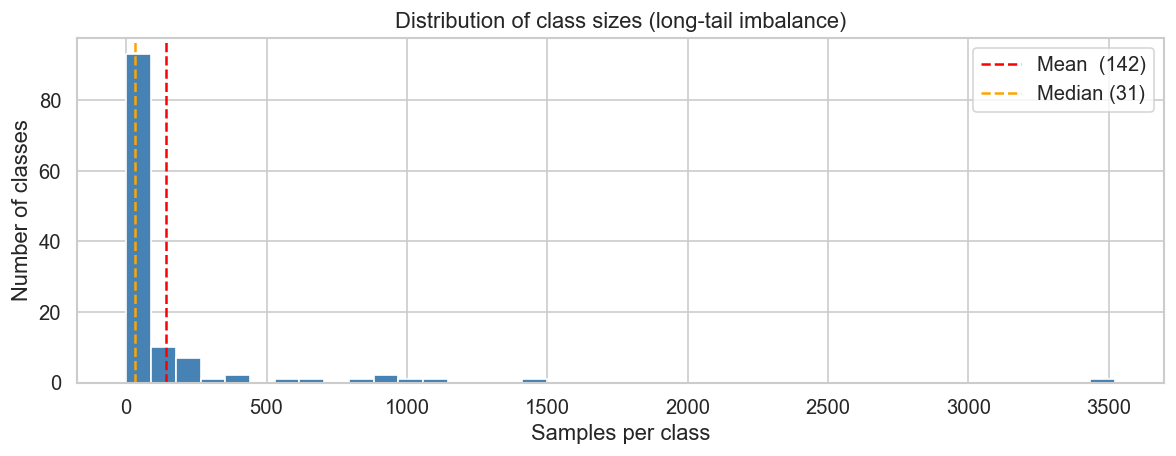

Mean samples/class  : 142.3
Median samples/class: 31.0
Std dev             : 390.2


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cat_counts.values, bins=40, color="steelblue", edgecolor="white")
ax.axvline(cat_counts.mean(), color="red",    linestyle="--", label=f"Mean  ({cat_counts.mean():.0f})")
ax.axvline(cat_counts.median(), color="orange", linestyle="--", label=f"Median ({cat_counts.median():.0f})")
ax.set_xlabel("Samples per class")
ax.set_ylabel("Number of classes")
ax.set_title("Distribution of class sizes (long-tail imbalance)")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "results" / "eda_class_size_histogram.png", bbox_inches="tight")
plt.show()

print(f"Mean samples/class  : {cat_counts.mean():.1f}")
print(f"Median samples/class: {cat_counts.median():.1f}")
print(f"Std dev             : {cat_counts.std():.1f}")

## 4. The 'Town' Problem — Subcategory Fragmentation

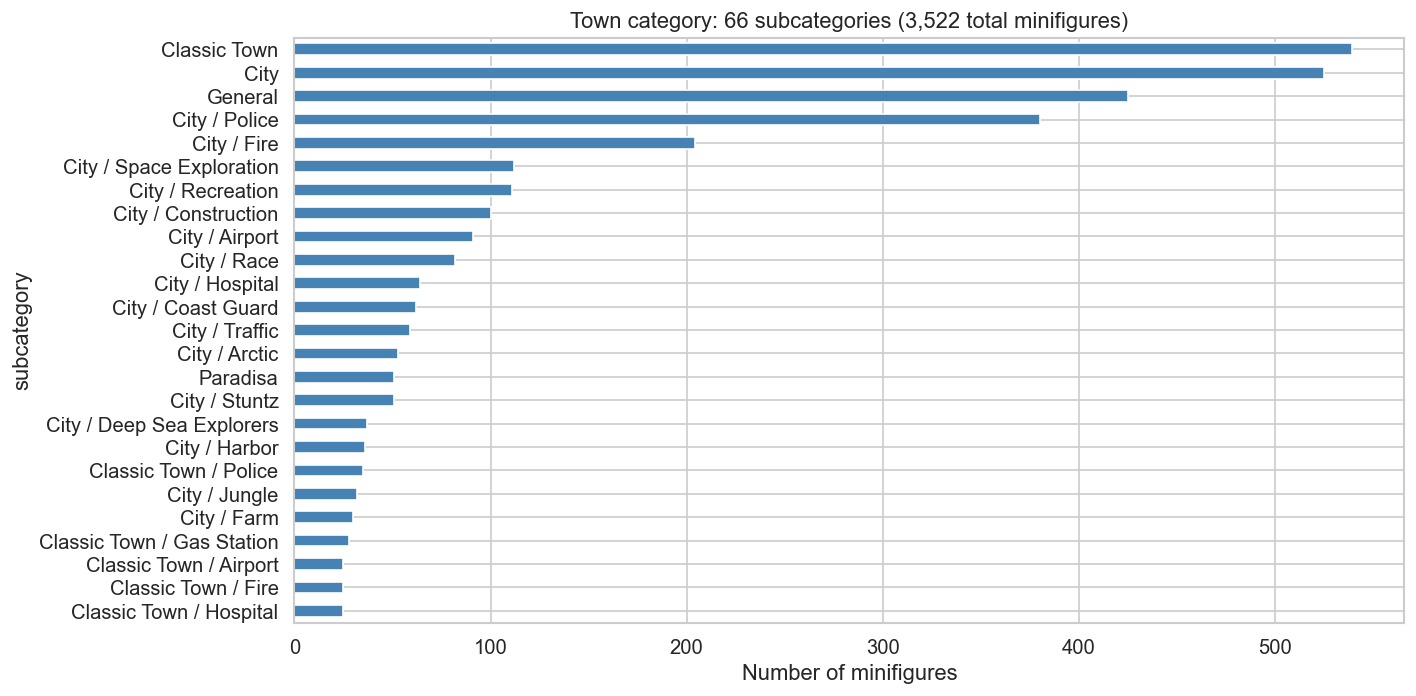

Town total samples : 3,522
Town subcategories : 66
Avg samples/subcat : 53.4

Insight: 'Town' is 1 label but spans 66 subcategories — explaining its near-zero F1 in the baseline model.


In [7]:
# Town is the largest category by far — look at its subcategories
town_df = df[df["category"] == "Town"]
town_subcats = town_df["subcategory"].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
town_subcats.head(25).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"Town category: {len(town_subcats)} subcategories ({len(town_df):,} total minifigures)")
ax.set_xlabel("Number of minifigures")
plt.tight_layout()
plt.savefig(ROOT / "results" / "eda_town_subcategories.png", bbox_inches="tight")
plt.show()

print(f"Town total samples : {len(town_df):,}")
print(f"Town subcategories : {len(town_subcats)}")
print(f"Avg samples/subcat : {len(town_df)/len(town_subcats):.1f}")
print("\nInsight: 'Town' is 1 label but spans", len(town_subcats),
      "subcategories — explaining its near-zero F1 in the baseline model.")

## 5. Temporal Analysis — Minifigures Over Time

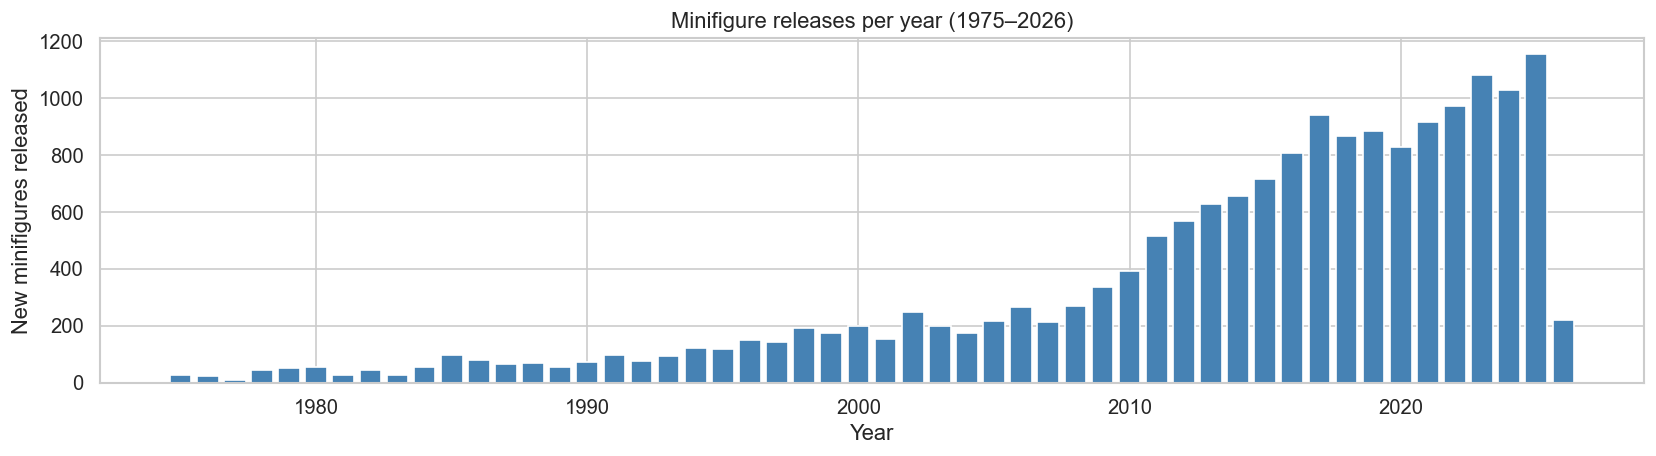

Releases per decade:
decade
1970     152
1980     567
1990    1225
2000    2271
2010    6959
2020    6188


In [8]:
year_df = df[df["year"].notna()].copy()
year_df["year"] = year_df["year"].astype(int)
year_counts = year_df["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(year_counts.index, year_counts.values, color="steelblue", width=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("New minifigures released")
ax.set_title("Minifigure releases per year (1975–2026)")
plt.tight_layout()
plt.savefig(ROOT / "results" / "eda_releases_per_year.png", bbox_inches="tight")
plt.show()

# Decade breakdown
year_df["decade"] = (year_df["year"] // 10) * 10
decade_counts = year_df.groupby("decade").size()
print("Releases per decade:")
print(decade_counts.to_string())

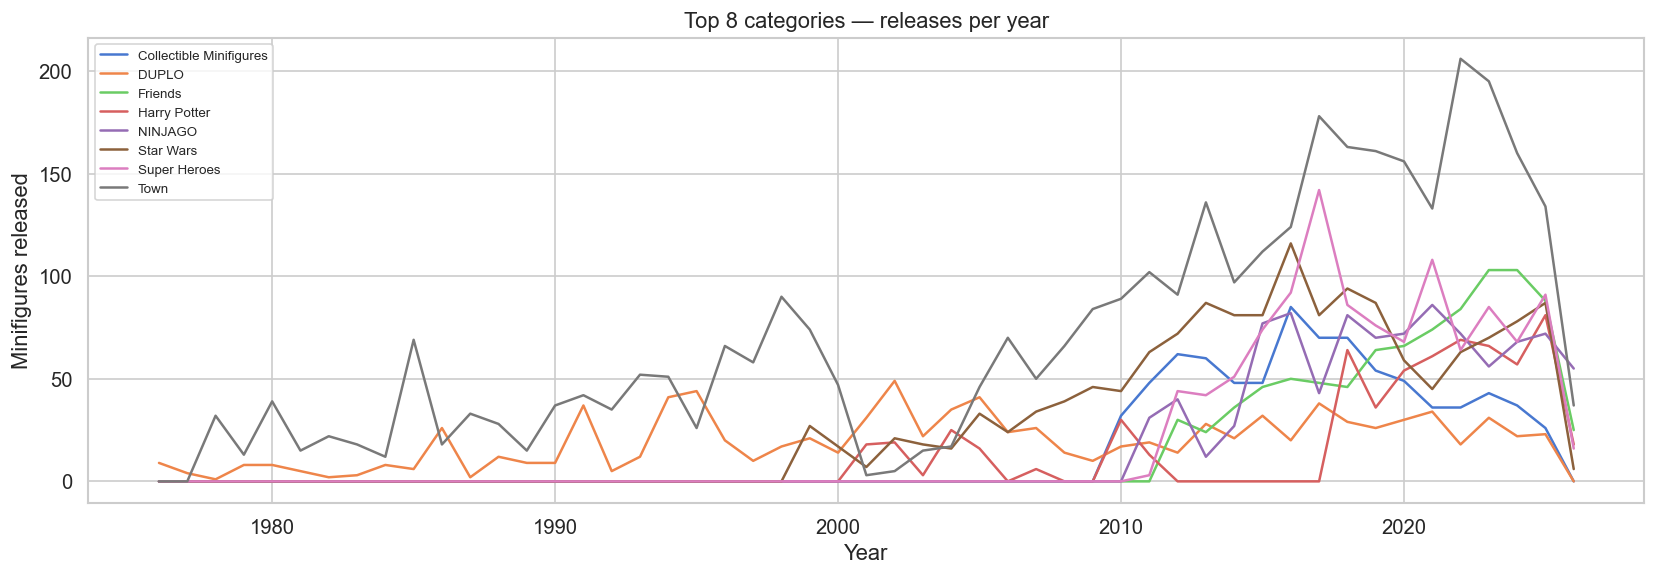

In [9]:
# Top categories over time — do themes come and go?
top_cats = cat_counts.head(8).index.tolist()
pivot = (
    year_df[year_df["category"].isin(top_cats)]
    .groupby(["year", "category"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
pivot.plot(ax=ax, linewidth=1.5)
ax.set_title("Top 8 categories — releases per year")
ax.set_xlabel("Year")
ax.set_ylabel("Minifigures released")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "results" / "eda_categories_over_time.png", bbox_inches="tight")
plt.show()

## 6. Image Analysis

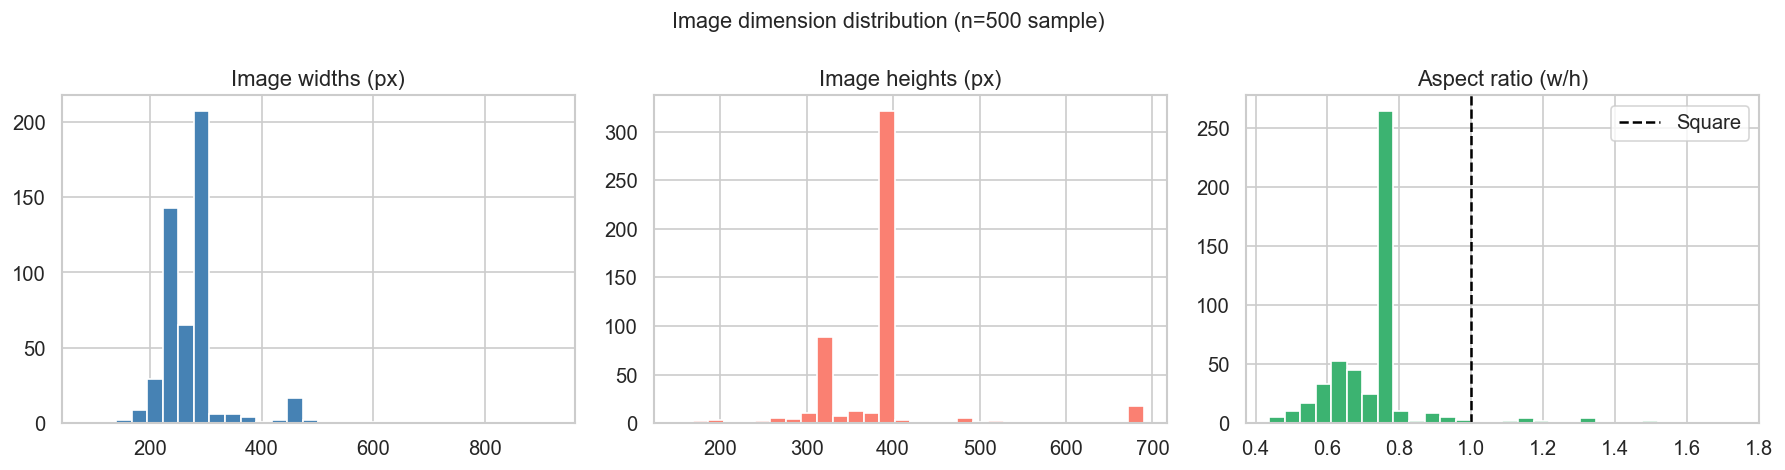

Width  — mean: 281px, std: 68px
Height — mean: 387px, std: 75px
Aspect — mean: 0.73, std: 0.15


In [10]:
# Sample 500 images and record their dimensions
valid = df[df["img_local_path"].notna()].copy()
sample_rows = valid.sample(500, random_state=42)

widths, heights, aspects = [], [], []
for path in sample_rows["img_local_path"]:
    full = ROOT / path
    try:
        w, h = Image.open(full).size
        widths.append(w)
        heights.append(h)
        aspects.append(w / h)
    except Exception:
        pass

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=30, color="steelblue")
axes[0].set_title("Image widths (px)")

axes[1].hist(heights, bins=30, color="salmon")
axes[1].set_title("Image heights (px)")

axes[2].hist(aspects, bins=30, color="mediumseagreen")
axes[2].axvline(1.0, color="black", linestyle="--", label="Square")
axes[2].set_title("Aspect ratio (w/h)")
axes[2].legend()

plt.suptitle("Image dimension distribution (n=500 sample)", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "results" / "eda_image_dimensions.png", bbox_inches="tight")
plt.show()

print(f"Width  — mean: {np.mean(widths):.0f}px, std: {np.std(widths):.0f}px")
print(f"Height — mean: {np.mean(heights):.0f}px, std: {np.std(heights):.0f}px")
print(f"Aspect — mean: {np.mean(aspects):.2f}, std: {np.std(aspects):.2f}")

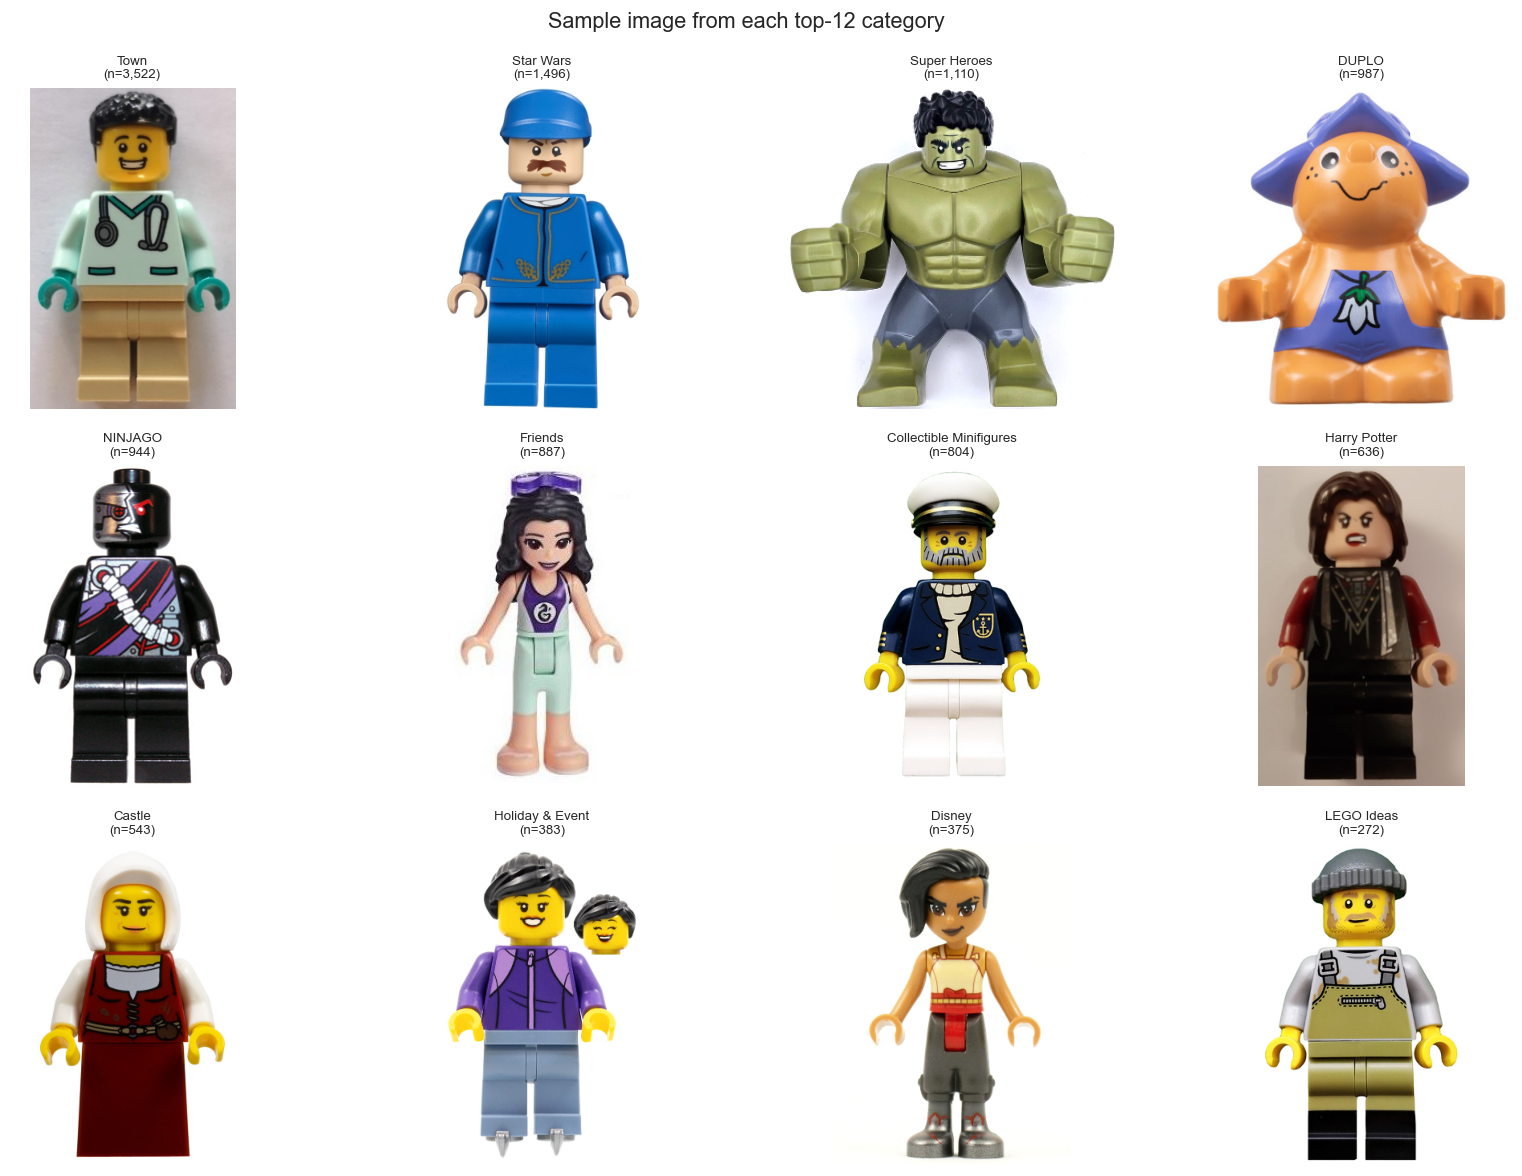

In [11]:
# Show a grid of sample images per category (top 12 categories)
top12 = cat_counts.head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for ax, cat in zip(axes, top12):
    cat_rows = df[df["category"] == cat].dropna(subset=["img_local_path"])
    row = cat_rows.sample(1, random_state=42).iloc[0]
    img_path = ROOT / row["img_local_path"]
    try:
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, "N/A", ha="center", va="center")
    ax.set_title(f"{cat}\n(n={cat_counts[cat]:,})", fontsize=8)
    ax.axis("off")

plt.suptitle("Sample image from each top-12 category", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "results" / "eda_sample_images.png", bbox_inches="tight")
plt.show()

## 7. Visually Similar Categories — Confusion Risk

In [12]:
# Groups of categories that share visual traits — likely to be confused
similar_groups = {
    "Superhero franchises": ["Super Heroes", "Batman"],
    "Space themes":         ["Space", "Space Police", "Blacktron"],
    "LEGO Movies":          ["The LEGO Movie", "The LEGO Movie 2"],
    "NINJAGO variants":     ["NINJAGO", "The LEGO Ninjago Movie"],
    "Friends / Fantasy":    ["Friends", "Elves"],
    "Town sub-themes":      ["Town", "City"],
}

rows = []
for group, cats in similar_groups.items():
    for c in cats:
        if c in cat_counts:
            rows.append({"Group": group, "Category": c, "Samples": cat_counts[c]})

risk_df = pd.DataFrame(rows)
print("Categories at high confusion risk (visually similar within group):")
print(risk_df.to_string(index=False))

Categories at high confusion risk (visually similar within group):
               Group         Category  Samples
Superhero franchises     Super Heroes     1110
        Space themes            Space      209
         LEGO Movies   The LEGO Movie       76
         LEGO Movies The LEGO Movie 2       85
    NINJAGO variants          NINJAGO      944
   Friends / Fantasy          Friends      887
   Friends / Fantasy            Elves       60
     Town sub-themes             Town     3522


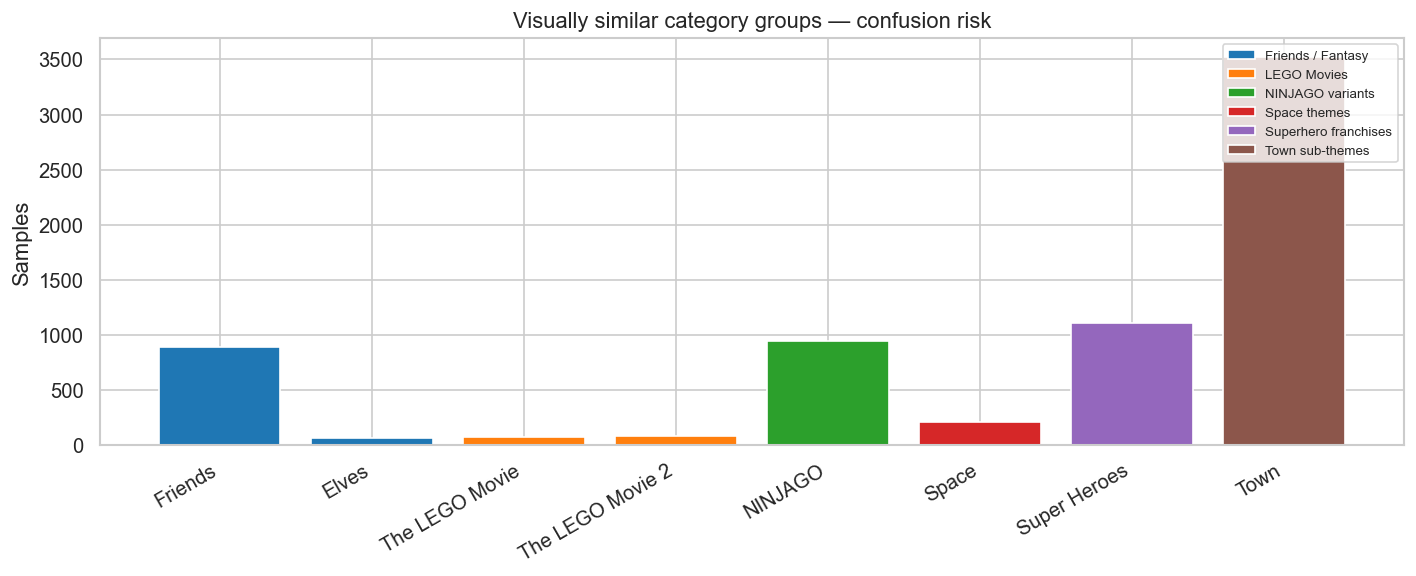

In [13]:
# Visualise the confusion-risk groups as a grouped bar chart
if not risk_df.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = plt.cm.tab10.colors
    group_list = risk_df["Group"].unique()
    for i, (group, gdf) in enumerate(risk_df.groupby("Group")):
        x = np.arange(len(gdf))
        ax.bar(
            [f"{row.Category}" for _, row in gdf.iterrows()],
            gdf["Samples"].values,
            color=colors[i % len(colors)],
            label=group,
        )
    ax.set_ylabel("Samples")
    ax.set_title("Visually similar category groups — confusion risk")
    ax.legend(loc="upper right", fontsize=8)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(ROOT / "results" / "eda_confusion_risk_groups.png", bbox_inches="tight")
    plt.show()

## 8. Key Insights Summary

In [14]:
pct_tiny = (cat_counts < 50).sum() / len(cat_counts) * 100
top1_pct = cat_counts.iloc[0] / n_total * 100

insights = [
    f"1. SEVERE IMBALANCE  : top class ('Town') holds {top1_pct:.1f}% of all samples; "
    f"{pct_tiny:.0f}% of classes have < 50 samples.",

    f"2. LONG-TAIL DISTRIBUTION : median class size is {int(cat_counts.median())} vs mean {cat_counts.mean():.0f}; "
    f"the largest class is {cat_counts.iloc[0] / cat_counts.iloc[-1]:.0f}x bigger than the smallest.",

    f"3. 'TOWN' FRAGMENTATION : largest category ({len(town_df):,} samples) spans "
    f"{len(town_subcats)} subcategories — effectively many tasks in one label. "
    "This caused near-zero baseline F1 for Town.",

    f"4. VISUAL SIMILARITY : at least 6 groups of categories share franchise aesthetics "
    "(e.g. NINJAGO vs LEGO Ninjago Movie, Friends vs Elves) — likely confusion sources "
    "even for a strong model.",

    f"5. VARIABLE IMAGE SIZE : images range widely in resolution (widths {min(widths)}–{max(widths)}px); "
    "all must be resized to a fixed input — information loss is unavoidable for high-res images "
    "downsampled to 128×128 (baseline) or 380×380 (V3).",

    f"6. GROWTH TREND : {decade_counts.get(2010, 0) + decade_counts.get(2020, 0):,} of "
    f"{n_total:,} minifigures were released in the 2010s–2020s — older themes are "
    "underrepresented, creating temporal bias.",
]

for ins in insights:
    print(ins)
    print()

1. SEVERE IMBALANCE  : top class ('Town') holds 20.3% of all samples; 64% of classes have < 50 samples.

2. LONG-TAIL DISTRIBUTION : median class size is 31 vs mean 142; the largest class is 3522x bigger than the smallest.

3. 'TOWN' FRAGMENTATION : largest category (3,522 samples) spans 66 subcategories — effectively many tasks in one label. This caused near-zero baseline F1 for Town.

4. VISUAL SIMILARITY : at least 6 groups of categories share franchise aesthetics (e.g. NINJAGO vs LEGO Ninjago Movie, Friends vs Elves) — likely confusion sources even for a strong model.

5. VARIABLE IMAGE SIZE : images range widely in resolution (widths 83–920px); all must be resized to a fixed input — information loss is unavoidable for high-res images downsampled to 128×128 (baseline) or 380×380 (V3).

6. GROWTH TREND : 13,147 of 17,362 minifigures were released in the 2010s–2020s — older themes are underrepresented, creating temporal bias.

